# 04. Inference

**Goal:** the ideas behind nnU-Net inference (sliding window and test-time mirroring), then visualize a prediction. Real inference needs a GPU, so we use an illustrative prediction built from the ground truth.

In [1]:
# bootstrap: make course_utils + scripts importable from any working directory,
# use the inline backend so figures render, and regenerate the phantom if missing.
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start


REPO = _find_repo_root(Path.cwd())
for _p in (str(REPO), str(REPO / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA = REPO / "assets" / "data" / "Dataset999_Phantom"
PRE = REPO / "assets" / "precomputed"

if not (DATA / "imagesTr" / "PHANTOM_001_0000.nii.gz").exists():
    import generate_phantom
    generate_phantom.generate(REPO / "assets" / "data")

print("repo root:", REPO.name)


repo root: internal-mini-course


## Sliding window and test-time augmentation

The model trained on fixed-size patches (for example 192 cubed), but scans are larger, so inference slides a window across the volume with overlap and blends the patches (Gaussian weighting). Test-time augmentation mirrors the input along axes and averages the predictions, which adds a small accuracy gain for extra compute.

Real command (read-only):
```bash
nnUNetv2_predict -i imagesTs -o preds -d 999 -c 3d_fullres -tr nnUNetTrainer_warmup1e3
```

In [2]:
import nibabel as nib
ct = np.asarray(nib.load(str(DATA / 'imagesTr' / 'PHANTOM_001_0000.nii.gz')).dataobj, dtype=np.float32)
gt = np.rint(np.asarray(nib.load(str(DATA / 'labelsTr' / 'PHANTOM_001.nii.gz')).dataobj)).astype(int)
from teaching_fixtures import illustrative_prediction
pred = illustrative_prediction(gt)   # illustrative, not a real model output
print('prediction voxels:', int((pred == 1).sum()), ' ground-truth voxels:', int((gt == 1).sum()))

prediction voxels: 539  ground-truth voxels: 877


## Visualize the prediction against the CT

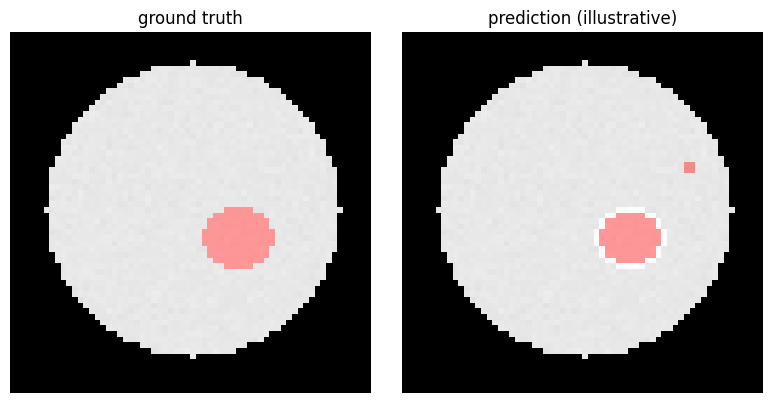

In [3]:
from course_utils.viz import overlay_mask_on_slice
z = gt.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
overlay_mask_on_slice(ct, gt, z=z, ax=axes[0]); axes[0].set_title('ground truth')
overlay_mask_on_slice(ct, pred, z=z, ax=axes[1]); axes[1].set_title('prediction (illustrative)')
fig.tight_layout()
plt.show()

## Recap
1. Inference slides a window over the volume and blends overlapping patches.
2. Mirroring at test time averages a few flips for a small gain.
3. The next notebooks reuse this illustrative prediction.